# Desafio 3: Modelo de lenguaje con tokenizacion por caracteres
## Alumno: Maxim Dorogov

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.\
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [55]:
from typing import Literal, List

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchinfo import summary
from torch import nn

import numpy as np
import gradio as gr
from tqdm import tqdm
from matplotlib import pyplot as plt


## Desarrollo

### Carga del dataset y tokenizacion

El dataset a utilizar es [Lovecraft Fiction](https://www.kaggle.com/datasets/bennijesus/lovecraft-fiction?resource=download), que contiene relatos, en idioma ingles, del autor H.P. Lovecraft.

In [2]:
# levantamos el archivo concat.txt el cual contiene todos los relatos concatenados.

DATA_PATH = '../desafio_2/data/concat.txt'
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    corpus = f.read()
# Elimino caracteres de salto de linea, retorno de carro y tabulacion
corpus = corpus.replace('\n', '')
corpus = corpus.replace('\r', '')
corpus = corpus.replace('\t', '')

print(f'Corpus length: {len(corpus)} characters')
print(f'Corpus sample: {corpus[:300]}')

Corpus length: 3851235 characters
Corpus sample: High up, crowning the grassy summit of a swelling mound whose sides are wooded near the basewith the gnarled trees of the primeval forest, stands the old chateau of my ancestors. For centuriesits lofty battlements have frowned down upon the wild and rugged countryside about, servingas a home and str


In [3]:
# Construimos vocabulario de caracteres y tokens

corpus = corpus.lower()
chars_vocab = set(corpus)

char2idx = {k: v for v,k in enumerate(chars_vocab)}  
idx2char = {v: k for k,v in char2idx.items()}

# Tokenizamos

tokenized_text = [char2idx[ch] for ch in corpus]
print(tokenized_text[:20])
print([idx2char[c] for c in tokenized_text[:20]])
print(f'Vocabulary size: {len(chars_vocab)} characters')

[23, 14, 92, 23, 56, 41, 89, 20, 56, 33, 84, 73, 34, 68, 14, 68, 92, 56, 8, 23]
['h', 'i', 'g', 'h', ' ', 'u', 'p', ',', ' ', 'c', 'r', 'o', 'w', 'n', 'i', 'n', 'g', ' ', 't', 'h']
Vocabulary size: 97 characters


### Fraccionamiento en secuencias

In [4]:
CONTEXT_WINDOW_SIZE = 100

# spliteamos en oraciones de largo CONTEXT_WINDOW_SIZE
tokenized_sentences = [
    tokenized_text[init:init + CONTEXT_WINDOW_SIZE] for
    init in range(len(tokenized_text) - CONTEXT_WINDOW_SIZE + 1)]
X = np.array(list(tokenized_sentences)[:-1])
y = np.array(list(tokenized_sentences)[1:])

# Nos queda un array de shape (N, CONTEXT_WINDOW_SIZE) donde N es la cantidad 
# de oraciones que se pudieron formar
print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (3851135, 100), y shape: (3851135, 100)


### Arquitecturas de las redes neuronales a utilizar

Se van a evaluar las siguientes arquitecturas:
1. SimpleRNN
2. LSTM
3. GRU

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [ ]:
class SimpleRNN(nn.Module):
    """
    Modelo de lenguaje basado en RNN simple.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the RNN hidden state. Default is 64.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=rnn_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = x.long()
        x = self.embedding(x)                
        out, _ = self.rnn(x)
        logits = self.fc(out)                     
        return logits                          

class SimpleLSTM(nn.Module):
    """
    Modelo de lenguaje basado en LSTM.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the LSTM hidden state. Default is 200.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.lstm1 = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.lstm2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, vocab_size)

    def forward(self, x):

        x = self.embedding(x)  # (batch, seq_len, embed_dim)
        x, _ = self.lstm1(x)   # (batch, seq_len, hidden_dim)

        x, (h_n, c_n) = self.lstm2(x)
        x = h_n[-1]

        x = F.relu(self.fc1(x))
        logits = self.fc2(x)           # (batch, vocab_size+1)
        return logits

In [22]:
model = SimpleRNN(vocab_size=len(chars_vocab)).to('cuda')

print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleRNN                                [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─RNN: 1-2                               [1, 100, 128]             51,712
├─Linear: 1-3                            [1, 100, 97]              12,513
Total params: 65,777
Trainable params: 65,777
Non-trainable params: 0
Total mult-adds (M): 5.19
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.26
Estimated Total Size (MB): 0.46


In [23]:
print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleRNN                                [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─RNN: 1-2                               [1, 100, 128]             51,712
├─Linear: 1-3                            [1, 100, 97]              12,513
Total params: 65,777
Trainable params: 65,777
Non-trainable params: 0
Total mult-adds (M): 5.19
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.26
Estimated Total Size (MB): 0.46


### Entrenamiento

Se realizara un split 80/20 para train y validation mediante un muestreo aleatorio
entre todos los chuncks de tamanio CONTEXT_WINDOW_SIZE. Esto se hace para obtener
secuencias de entrenamiento provenientes de distintas partes del corpus.

In [24]:
BATCH_SIZE = 256
VAL_SPLIT = 0.2

dataset = TensorDataset(
    torch.tensor(X, dtype=torch.long), 
    torch.tensor(y, dtype=torch.long))

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [1 - VAL_SPLIT, VAL_SPLIT])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [25]:
def perplexity(loss_value: float) -> float:
    try:
        perplexity = np.exp(loss_value)
    except OverflowError:
        perplexity = float('inf')
    return perplexity

def evaluate(model, data_loader, loss_fn) -> tuple[float, float]:
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input, target in tqdm(data_loader, desc="Validation"):
            input, target = input.to(device), target.to(device)
            logits = model(input)
            loss = loss_fn(logits.transpose(1, 2), target)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    ppl = perplexity(avg_loss)
    return avg_loss, ppl

In [33]:
# --- training loop ---
EPOCHS = 10

model = SimpleRNN(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg = list()
val_loss_avg = list()
train_ppl = list()
val_ppl = list()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for input, target in tqdm(
        train_dataloader, desc=f"Training: Epoch {epoch+1}/{EPOCHS}"):

        input, target = input.to(device), target.to(device)
        optimizer.zero_grad()
        logits = model(input)  # logits: (batch, seq_len, vocab_size)

        loss = criterion(logits.transpose(1, 2), target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # training metrics
    train_loss_avg.append(epoch_loss / len(train_dataloader))
    train_ppl.append(perplexity(loss_value=train_loss_avg[-1]))

    # learning rate scheduler step monitoreando la loss de entrenamiento
    lr_scheduler.step(train_loss_avg[-1])

    # evaluation metrics
    eval_loss, eval_ppl = evaluate(model, val_dataloader, criterion)
    val_loss_avg.append(eval_loss)
    val_ppl.append(eval_ppl)

    print(f"train loss: {train_loss_avg[-1]:.3f}",
          f" - val loss: {val_loss_avg[-1]:.3f}",
          f" - train ppl: {train_ppl[-1]:.4f} - val ppl: {val_ppl[-1]:.4f}")



Training: Epoch 1/10:   0%|          | 0/12035 [00:00<?, ?it/s]

Validation: 100%|██████████| 3009/3009 [00:05<00:00, 507.41it/s]


train loss: 1.898  - val loss: 1.780  - train ppl: 6.6701 - val ppl: 5.9316


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 519.39it/s]


train loss: 1.746  - val loss: 1.744  - train ppl: 5.7301 - val ppl: 5.7208


...

train loss: 1.679  - val loss: 1.676  - train ppl: 5.3623 - val ppl: 5.3437


Validation: 100%|██████████| 3009/3009 [00:07<00:00, 391.43it/s]


train loss: 1.674  - val loss: 1.674  - train ppl: 5.3335 - val ppl: 5.3324


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 518.03it/s]

train loss: 1.672  - val loss: 1.672  - train ppl: 5.3236 - val ppl: 5.3247


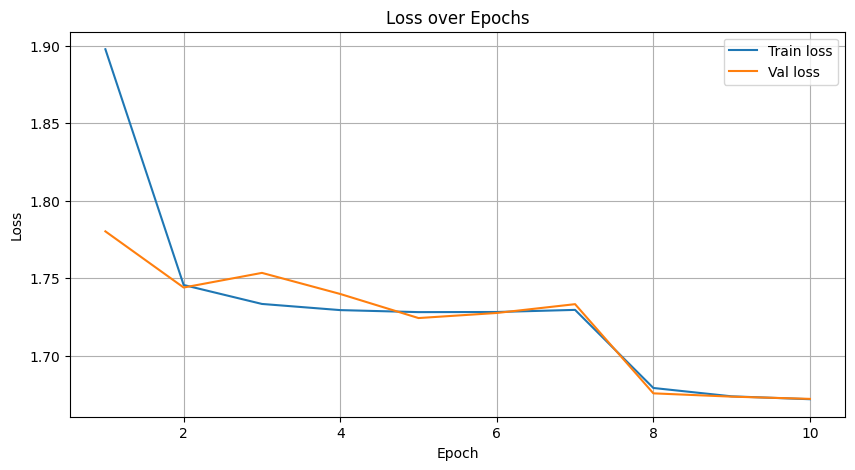

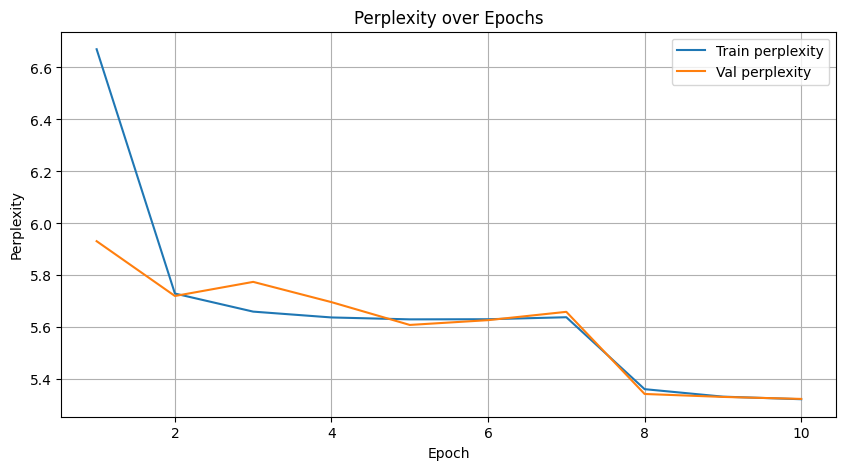

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_loss_avg)
plt.plot(range(1, EPOCHS + 1), val_loss_avg)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend(['Train loss', 'Val loss'])
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_ppl)
plt.plot(range(1, EPOCHS + 1), val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

In [ ]:
torch.save(model.state_dict(), "simple_rnn.pth")

In [ ]:
def inference_greedy(model: nn.Module, seed_text: str, n_chars: int) -> str:
    """
    Generates a text sequence from a seed text using
    a trained language model and a greedy sampling strategy.

    Parameters
    ----------
    model : nn.Module
        Trained language model.
    seed_text : str
        Seed text to start generation.
    n_chars : int
        Number of characters to generate.
    
    Returns
    -------
    str
        Generated text.
    """
    model.eval()
    device = next(model.parameters()).device # reads model device
    output_text = seed_text

    for _ in range(n_chars):
        encoded = [char2idx.get(ch) for ch in output_text.lower()]

        # to tensor (batch=1, seq_len=max_length, 1)
        x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

        # --- Forward ---
        with torch.no_grad():
            logits = model(x)
            probs = F.softmax(logits[0, -1, :], dim=-1)
            y_hat = torch.argmax(probs).item()

        # convertir a caracter
        out_char = idx2char[y_hat]
        output_text += out_char

    return output_text

def select_candidates(
    probs: List[np.ndarray], 
    top_k: int, 
    vocab_size: int, 
    history_probs: List[float], 
    history_tokens: List[np.ndarray],
    mode: Literal['det', 'sto'] = 'det', 
    temp: float = 1.0):
    """
    preds: List[np.ndarray]
        Model predictions (probabilidades) of shape vocab_size for each beam
        [[beam_1_probs], [beam_2_probs], ...]
    top_k: int
        Number of candidates to select
    vocab_size: int
        Size of the vocabulary
    history_probs: List[float]
        List of accumulated log-probs so far
    history_tokens: List[np.ndarray]
        List of token sequences so far
    """

    # Compute log prob over the flattened list of lists of predictions
    acc_log_probs = list()
    for idx, pred in enumerate(probs):
        log_probs = np.log(pred + 1e-10)
        acc_log_probs.extend(log_probs + history_probs[idx])
    
    acc_log_probs = np.array(acc_log_probs)

    if mode == 'det':
        # select the top_k log_probs (closest to 0) and accumulate
        topk_idxes = np.argsort(acc_log_probs)[::-1][:top_k]
    elif mode == 'sto':

        safe_temp = max(temp, 1e-6)
        shifted = acc_log_probs - acc_log_probs.max()
        scaled = np.exp(shifted / safe_temp)
        total = scaled.sum()
        if not np.isfinite(total) or total <= 0:
            scaled = np.full_like(scaled, 1.0 / scaled.size)
        else:
            scaled = scaled / total
        topk_idxes = np.random.choice(
            np.arange(acc_log_probs.shape[0]), top_k, p=scaled)

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[topk_idxes // vocab_size],
         np.array([topk_idxes % vocab_size]).T),
        axis=1)

    return acc_log_probs[topk_idxes.astype(int)], new_history_tokens

def inference_beamsearch(
        model: nn.Module,
        input_text: str,
        n_chars: int,
        top_k: int = 3,
        temp: float = 1.0,
        mode: Literal['det', 'sto'] = 'det'
    ):
    """
    Generates a text sequence from a seed text using a trained language model 
    and a beam search sampling strategy.
    """
    model.eval()
    device = next(model.parameters()).device

    encoded = [char2idx.get(ch) for ch in input_text.lower()]
    x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        preds = F.softmax(logits[0, -1, :], dim=-1).cpu().numpy()

    vocab_size = preds.shape[0]

    # initial probabilities
    accum_probs = [0] * top_k # log prob acumuladed per each beam
    history_tokens = [encoded] * top_k

    # select initial candidates
    accum_probs, history_tokens = select_candidates(
        probs=[preds],
        top_k=top_k,
        vocab_size=vocab_size,
        history_probs=accum_probs,
        history_tokens=history_tokens,
        temp=temp,
        mode=mode)

    #loop beam search
    for _ in range(n_chars):
        preds = []
        # loop over each beam
        for input in history_tokens:
            x = torch.tensor(input, dtype=torch.long).unsqueeze(0).to(device)
            with torch.no_grad():
                logits = model(x)
                y_hat = F.softmax(logits[0, -1, :], dim=-1).cpu().numpy()
            preds.append(y_hat)

        accum_probs, history_tokens = select_candidates(
            probs=preds,
            top_k=top_k,
            vocab_size=vocab_size,
            history_probs=accum_probs,
            history_tokens=history_tokens,
            temp=temp,
            mode=mode)

        # Return the top-k most probable sequences and their log probabilities
        # convert secuences to chars

        text_secs = [
            ''.join([idx2char[t] for t in tokens]) for tokens in history_tokens]

    return accum_probs, text_secs


In [163]:
log_probs, text_seqs = inference_beamsearch(model, "insm", n_chars=100, top_k=3, mode='sto')

print(log_probs)
print(text_seqs)

/tmp/ipykernel_18760/182225985.py:78: RuntimeWarning: invalid value encountered in divide
  scaled = scaled / scaled.sum()


ValueError: probabilities contain NaN